In [12]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans

In [13]:
df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [16]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


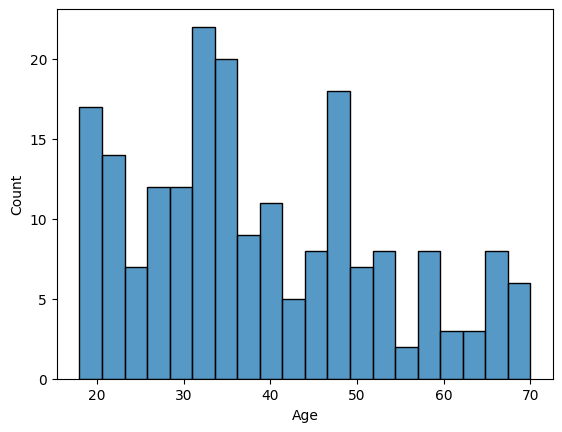

In [17]:
sns.histplot(df['Age'], bins=20)
plt.show()

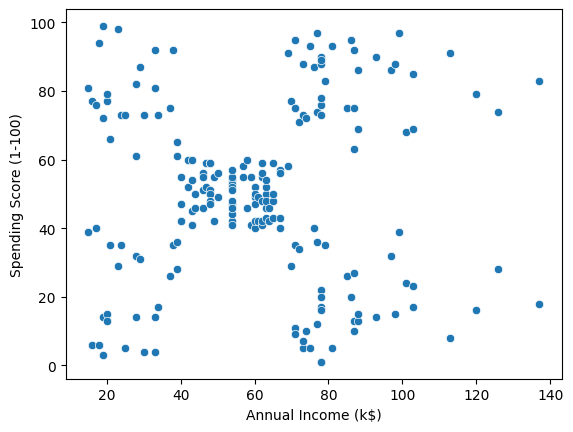

In [18]:
sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)'
)

plt.show()

In [19]:
X = df[['Annual Income (k$)',
        'Spending Score (1-100)']]

In [20]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

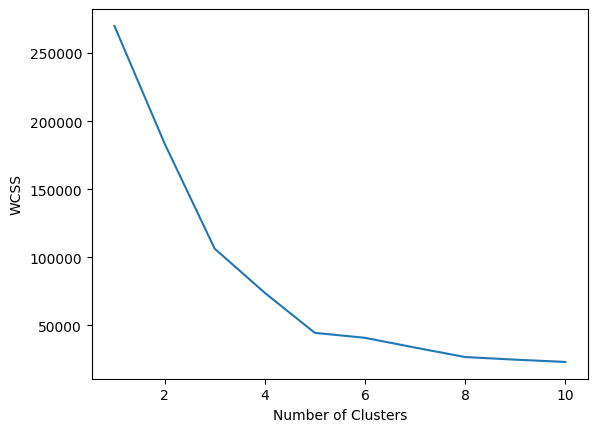

In [21]:
plt.plot(range(1,11), wcss)

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [22]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

df['Cluster'] = kmeans.fit_predict(X)

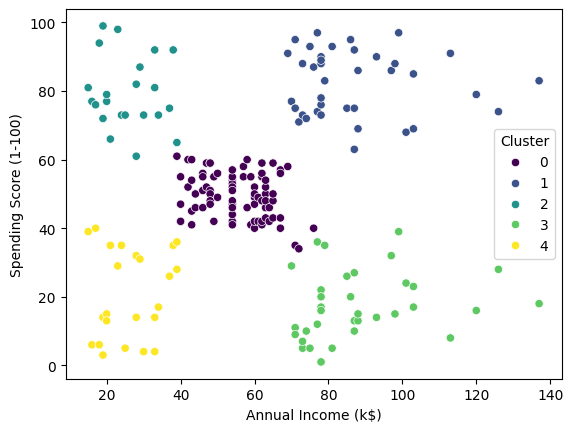

In [23]:
sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='viridis'
)

plt.show()

In [26]:
df.groupby('Cluster')[
    [
    'Age',
    'Annual Income (k$)',
    'Spending Score (1-100)'
    ]
].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


In [28]:
cluster_summary = df.groupby('Cluster')[
    [
        'Age',
        'Annual Income (k$)',
        'Spending Score (1-100)'
    ]
].mean()

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


In [29]:
segment_names = {
    0: "Budget Customers",
    1: "Careful Rich Customers",
    2: "Premium Customers",
    3: "Young Impulsive Customers",
    4: "Average Customers"
}

In [30]:
df['Customer Segment'] = df['Cluster'].map(segment_names)

In [31]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Customer Segment
0,1,Male,19,15,39,4,Average Customers
1,2,Male,21,15,81,2,Premium Customers
2,3,Female,20,16,6,4,Average Customers
3,4,Female,23,16,77,2,Premium Customers
4,5,Female,31,17,40,4,Average Customers


In [32]:
df['Customer Segment'].value_counts()

,count
Customer Segment,
Budget Customers,81
Careful Rich Customers,39
Young Impulsive Customers,35
Average Customers,23
Premium Customers,22


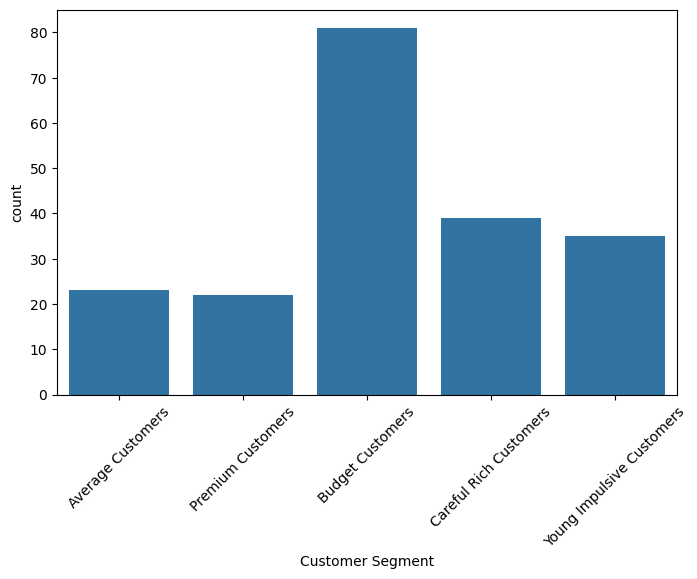

In [33]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Customer Segment'
)

plt.xticks(rotation=45)

plt.show()

In [34]:
df.to_csv(
    "customer_segments.csv",
    index=False
)

In [35]:
def predict_customer_segment(age, income, spending_score):

    customer = [[income, spending_score]]

    cluster = kmeans.predict(customer)[0]

    return segment_names[cluster]

In [36]:
predict_customer_segment(
    age=25,
    income=90,
    spending_score=85
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


'Careful Rich Customers'

In [37]:
predict_customer_segment(
    age=45,
    income=20,
    spending_score=15
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


'Average Customers'